# Integration Refresher

This refresher is about integration skills you are expected to bring into multivariable calculus.  The goal is to remind you of integration concepts you learned previously to make sure you can confidently handle the one-variable integration steps that will appear inside multivariable problems.

By the end, you should be comfortable with:

- Simplifying an expression before integrating;
- Using the power rule for indefinite integrals;
- Recognising when logarithms appear;
- Using substitution;
- Using integration by parts;
- Understanding definite integrals as limits of Riemann sums;
- Checking whether your answer differentiates back to the integrand.

**Caveat**: solutions to the exercises below are partially AI generated, with quality checking.  They may contain errors or use unusual steps.


## What an indefinite integral means

An indefinite integral asks for an antiderivative.

If

$$
F'(x)=f(x),
$$
then

$$
\int f(x)\,dx = F(x)+C.
$$

The constant $C$ is important because many different functions have the same derivative. For example,

$$
\frac{d}{dx}\left(x^3+7\right)=3x^2
$$
and

$$
\frac{d}{dx}\left(x^3-100\right)=3x^2.
$$
So

$$
\int 3x^2\,dx=x^3+C.
$$

### Check your answer

The simplest way to check an indefinite integral is to differentiate your result.

Example:

$$
\int x^2\,dx=\frac{x^3}{3}+C.
$$
Check:

$$
\frac{d}{dx}\left(\frac{x^3}{3}+C\right)=x^2.
$$



## Definite integrals and Riemann sums

Before learning double and triple integrals, it is important to remember what a one-variable definite integral means.

A definite integral

$$
\int_a^b f(x)\,dx
$$

can be interpreted as the signed area between the graph of $f(x)$ and the $x$-axis from $x=a$ to $x=b$. We use a ``signed area'' meaning:

- Area above the $x$-axis contributes positively.
- Area below the $x$-axis contributes negatively.

### Riemann sum idea

To estimate the area under a curve, divide the interval $[a,b]$ into many small pieces. If each piece has width $\Delta x$, and $x_i^*$ is a sample point in the $i$ th piece, then

$$
\sum_{i=1}^n f(x_i^*)\Delta x
$$

approximates the area.


In this subject, we will use the **left endpoint** of each interval for $x_i$ unless stated otherwise.


#### Example

Approximate

$$
\int_0^2 x^2\,dx
$$
using $n=4$ rectangles.
Here

$$
\Delta x=\frac{2-0}{4}=\frac{1}{2}.
$$

The left endpoints are

$$
0, \frac{1}{2}, 1, \frac{3}{2}.
$$



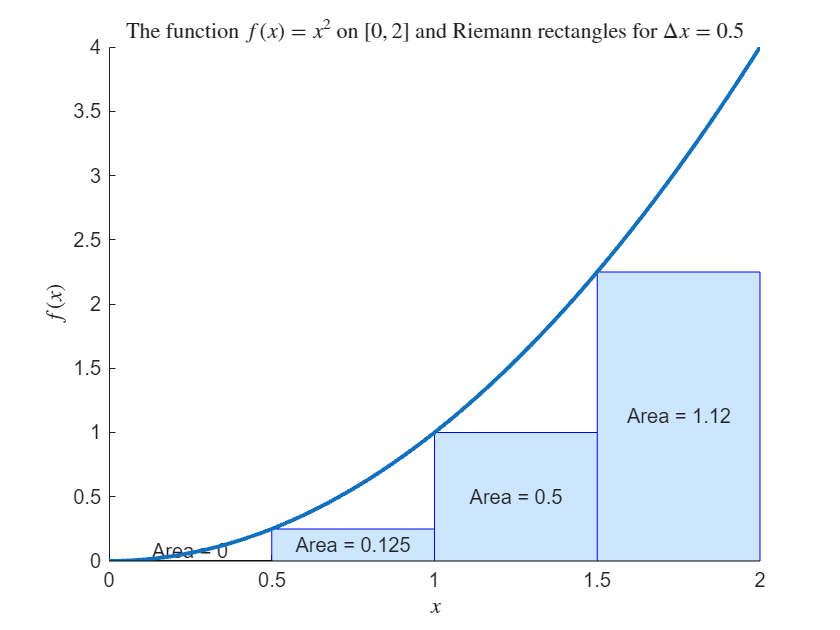

The Riemann sum is 1.7500.


In [1]:
% Plot f(x) = x^2 on [0,2] and illustrate the left-endpoint
% Riemann sum using n = 4 rectangles.
%
% Each rectangle is labelled with its area.


a = 0;
b = 2;
n = 4;

Delta_x = (b-a)/n;

% Left endpoints
x_left = a + (0:n-1)*Delta_x;

% Function values at the left endpoints
heights = x_left.^2;

% Areas of the rectangles
areas = heights * Delta_x;

% Riemann sum
riemann_sum = sum(areas);

% Plot the function
x = linspace(a,b,400);
y = x.^2;

figure
hold on

% Draw rectangles first
for i = 1:n
    left = x_left(i);
    height = heights(i);
    area = areas(i);

    rectangle('Position',[left,0,Delta_x,height], ...
              'FaceColor',[0.8 0.9 1.0], ...
              'EdgeColor','b')

    % Label each rectangle by its area.
    % For the first rectangle the height is 0, so place the label slightly above the axis.
    label_x = left + Delta_x/2;
    label_y = max(height/2, 0.08);

    text(label_x,label_y,sprintf('Area = %.3g',area), ...
         'HorizontalAlignment','center', ...
         'VerticalAlignment','middle')
end

% Plot the curve on top of the rectangles
plot(x,y,'LineWidth',2)

% Plot the x-axis
plot([a b],[0 0],'k')

xlabel('$x$','Interpreter','latex')
ylabel('$$f(x)$','Interpreter','latex')

title('The function $f(x) = x^2$ on $[0,2]$ and Riemann rectangles for $\Delta x = 0.5$','Interpreter','latex')

fprintf('The Riemann sum is %.4f.\n',riemann_sum)



So the Riemann sum is

$$
\left[0^2+\left(\frac{1}{2}\right)^2+1^2+\left(\frac{3}{2}\right)^2\right]\frac{1}{2}.
$$

That is

$$
\left(0+\frac{1}{4}+1+\frac{9}{4}\right)\frac{1}{2}
=\frac{7}{2}\cdot\frac{1}{2}
=\frac{7}{4}.
$$

#### Improving the approximation

The definite integral is the limit of these sums as the pieces become thinner:

$$
\int_a^b f(x)\,dx = \lim_{\Delta x\to 0}\sum_{i=1}^n f(x_i^*)\Delta x.
$$
with

$$
n \Delta x=b-a.
$$

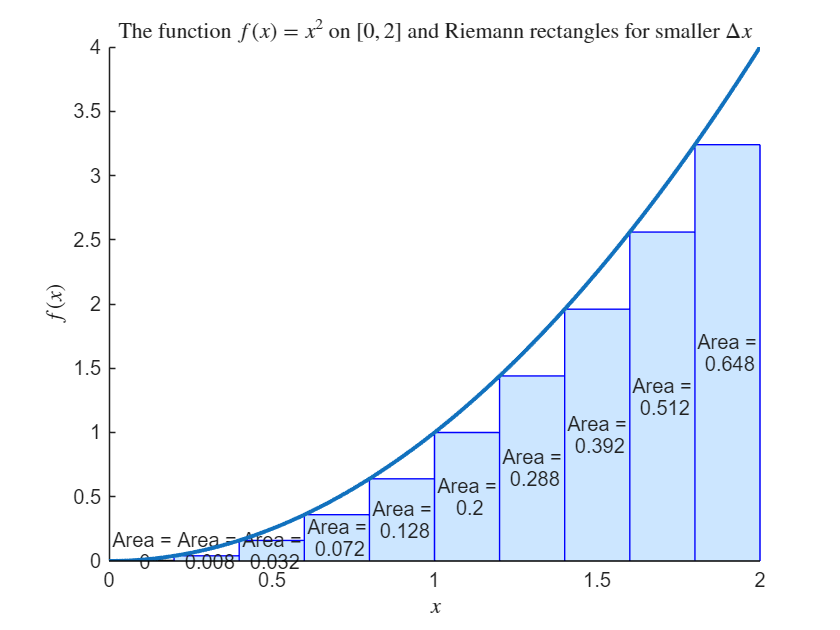

The Riemann sum is 2.2800.


In [6]:
% Plot f(x) = x^2 on [0,2] and illustrate the left-endpoint
% Riemann sum using n = 4 rectangles.
%
% Each rectangle is labelled with its area.


a = 0;
b = 2;
n = 10;

Delta_x = (b-a)/n;

% Left endpoints
x_left = a + (0:n-1)*Delta_x;

% Function values at the left endpoints
heights = x_left.^2;

% Areas of the rectangles
areas = heights * Delta_x;

% Riemann sum
riemann_sum = sum(areas);

% Plot the function
x = linspace(a,b,400);
y = x.^2;

figure
hold on

% Draw rectangles first
for i = 1:n
    left = x_left(i);
    height = heights(i);
    area = areas(i);

    rectangle('Position',[left,0,Delta_x,height], ...
              'FaceColor',[0.8 0.9 1.0], ...
              'EdgeColor','b')

    % Label each rectangle by its area.
    % For the first rectangle the height is 0, so place the label slightly above the axis.
    label_x = left + Delta_x/2;
    label_y = max(height/2, 0.08);

    text(label_x,label_y,sprintf('Area =\n %.3g',area), ...
         'HorizontalAlignment','center', ...
         'VerticalAlignment','middle')
end

% Plot the curve on top of the rectangles
plot(x,y,'LineWidth',2)

% Plot the x-axis
plot([a b],[0 0],'k')

xlabel('$x$','Interpreter','latex')
ylabel('$f(x)$','Interpreter','latex')

title('The function $f(x) = x^2$ on $[0,2]$ and Riemann rectangles for smaller $\Delta x$','Interpreter','latex')

fprintf('The Riemann sum is %.4f.\n',riemann_sum)


This is a better approximation than with $\Delta x  = 0.5$, but it is not exact. The exact value is

$$
\int_0^2 x^2\,dx=\left[\frac{x^3}{3}\right]_0^2=\frac{8}{3}.
$$

We can compare the approximation with the exact value as we increase the number of rectangles. As $n$ increases, the rectangles become thinner, and the Riemann sum should get closer to the definite integral.

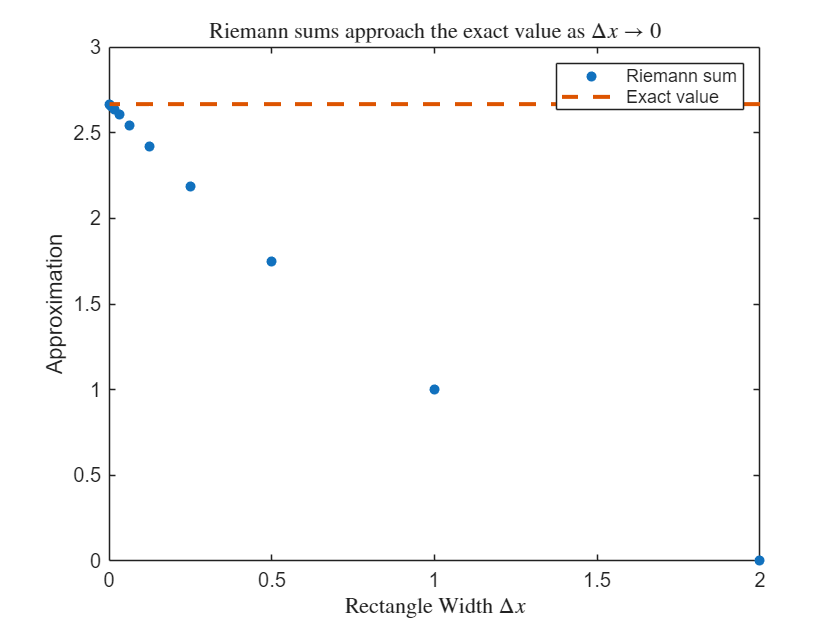

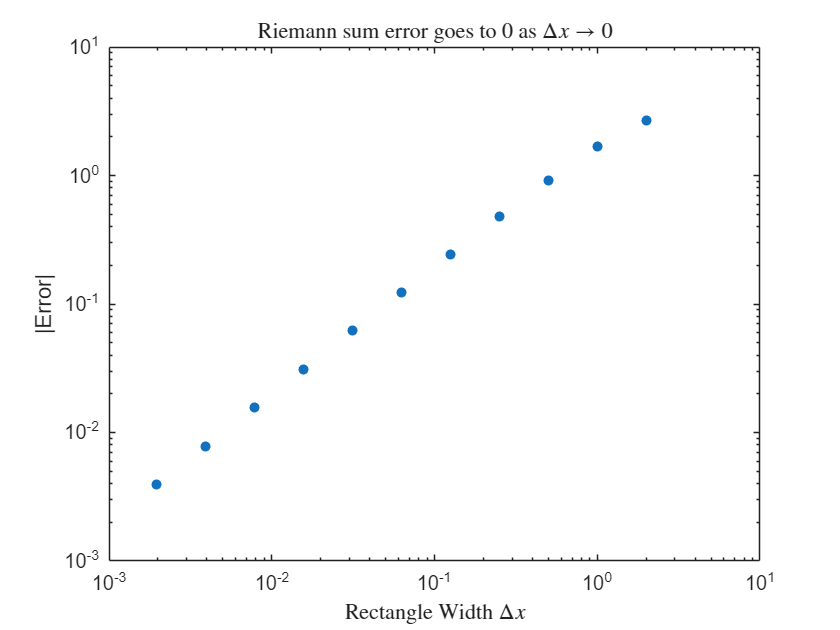

In [16]:
% Plot how the left-endpoint Riemann sum changes as n increases,
% and plot the absolute error on a log scale.


a = 0;
b = 2;
exact_value = 8/3;

n_values = 2.^[0:10];
Delta_x_values = (b-a)./n_values;
riemann_sums = zeros(size(n_values));
abs_errors = zeros(size(n_values));

for k = 1:length(n_values)
    n = n_values(k);
    Delta_x = Delta_x_values(k);
    x_left = a + (0:n-1)*Delta_x;
    riemann_sums(k) = sum(x_left.^2)*Delta_x;
    abs_errors(k) = abs(exact_value - riemann_sums(k));
end

figure
plot(Delta_x_values,riemann_sums, '.', 'MarkerSize',15)
hold on
plot(Delta_x_values,exact_value*ones(size(Delta_x_values)),'--','LineWidth',2)
xlabel('Rectangle Width  $\Delta x$','Interpreter','latex')
ylabel('Approximation')
title('Riemann sums approach the exact value as $\Delta x \to 0$','Interpreter','latex')
legend('Riemann sum','Exact value','Location','northeast')


figure
loglog(Delta_x_values,abs_errors,'.','MarkerSize',15    )
xlabel('Rectangle Width  $\Delta x$','Interpreter','latex')
ylabel('|Error|')
title('Riemann sum error goes to $0$ as $\Delta x \to 0$','Interpreter','latex')


#### Why Riemann sums matter later

In multivariable calculus, double integrals and triple integrals are built from the same idea: divide a region into small pieces, approximate the contribution from each piece, add them up, and take a limit. For now, the key point is that an integral is not just a formula. It represents a limiting sum.

### Self-test
1. 

````{tab-set}
```{tab-item} Question
Use Riemann sums to approximate the integral $\int_0^4 x^3-x^2 \, dx$ with $\Delta x = 1$ and $\Delta x = 0.5$.  Compare it with the true answer
```
```{tab-item} Solution

For $\Delta x=1$,

$$
\int_0^4 x^3-x^2\,dx \approx 22.
$$

For $\Delta x=0.5$,

$$
\int_0^4 x^3-x^2\,dx \approx \frac{63}{2}= 31 \frac{1}{2}
$$

The true answer is 

$$
\frac{128}{3} = 42 \frac{2}{3}
$$
```

```{tab-item} Worked solution

The function is

$$
f(x)=x^3-x^2.
$$

For $\Delta x=1$, the left endpoints are

$$
0,1,2,3.
$$

So

$$
\int_0^4 x^3-x^2\,dx
\approx
\left[f(0)+f(1)+f(2)+f(3)\right]\Delta x.
$$

Now

\begin{align*}
f(0)&=0\\
f(1)&=1^3-1^2\\
    &=0\\
f(2)&=2^3-2^2=8-4\\
&=4\\
f(3)&=3^3-3^2=27-9\\
&=18.
\end{align*}

Therefore

$$
\left[0+0+4+18\right](1)=22.
$$

So, for $\Delta x=1$,

$$
\int_0^4 x^3-x^2\,dx \approx 22.
$$

For $\Delta x=0.5$, the left endpoints are

$$
0,0.5,1,1.5,2,2.5,3,3.5.
$$

We found $f(x)$ at half of these already.

$$
\int_0^4 x^3-x^2\,dx
\approx
\left[
f(0)+f(0.5)+f(1)+f(1.5)+f(2)+f(2.5)+f(3)+f(3.5)
\right](0.5).
$$

The function values are

\begin{align*}
f(0)&=0\\
f(0.5)&=0.5^3-0.5^2=\frac{1}{8}-\frac{1}{4}\\ 
&=-\frac{1}{8}\\
f(1)&=0\\
f(1.5)&=1.5^3-1.5^2=\frac{27}{8}-\frac{9}{4}\\
&=\frac{9}{8}\\
f(2)&=4\\
f(2.5)&=2.5^3-2.5^2=\frac{125}{8}-\frac{25}{4}\\
&=\frac{75}{8}\\
f(3)&=18\\
f(3.5)&=3.5^3-3.5^2=\frac{343}{8}-\frac{49}{4}\\
&=\frac{245}{8}
\end{align*}

Thus

$$
\int_0^4 x^3-x^2\,dx
\approx
\left[
0-\frac{1}{8}+0+\frac{9}{8}+4+\frac{75}{8}+18+\frac{245}{8}
\right]\frac{1}{2}.
$$

The sum inside the brackets is

$$
63.
$$

Therefore

$$
\int_0^4 x^3-x^2\,dx
\approx
\frac{63}{2}.
$$

The true answer is
\begin{align*}
\int_0^4 x^3- x^2 \, dx &= \left.\frac{x^4}{4} - \frac{x^3}{3} \right|_0^4\\
&= 4^3 - \frac{4^3}{3} - 0\\
&= \frac{2}{3} 4^3\\
&= \frac{128}{3}
\end{align*}
```
````

```{dropdown} Extension Questions
These are more advanced questions intended for students who want to go beyond what is required for the subject.  

The questions below are related to the accuracy of the approximation as $\Delta x$ shrinks.  

1. We want to understand the error in the Riemann sums
   - Assume $f(x) = mx+b$ is a straight line.  Find the error in the Riemann sum approximation of $\int_0^1 f(x)\, dx$ in terms of $dx$.  
   - To more accurately estimate the error for other functions, write $f(x)$ in an interval $(x_i,x_i+\Delta x)$ using a Taylor Series about $x_i$:  
     $$
     f(x) \approx f(x_i) + (x-x_i) f'(x_i) + \frac{(x-x_i)^2}{2} f''(x_i) + \cdots
     $$
     Find the value of $\int_{x_i}^{x_i+\Delta x} f(x) \, dx$ using this expansion. 
   - What is the leading order (in $\Delta x$) error between the calculated area and the approximation from the rectangle for the strip from $x_i$ to $x_i+\Delta x$?  
   - Assuming $|f'(x)|<k$, find a bound on the sums of the leading order errors over all strips in terms of $\Delta x$.
   - Use this to explain the slope of the error in the log-log plot.
2. Consider what would happen if you used the midpoint rather than the left point of each interval to approximate the value of $f$.
   - Explain visually why this should be more accurate.
   - Assume $f(x) = mx+b$ is a straight line.  Find the error in the Riemann sum approximation of $\int_0^1 f(x)\, dx$ in terms of $dx$.
   - To more accurately estimate the error for other functions, write $f(x)$ in an interval $(x_i,x_i+\Delta x)$ using a Taylor Series about $\hat{x}_i = x_i + \frac{\Delta x}{2}$:  
     $$
    f(x) \approx f(\hat{x}_i) + (x-\hat{x}_i) f'(\hat{x}_i) + \frac{(x-\hat{x}_i)^2}{2} f''(\hat{x_i}) + \cdots
    $$  
    Find the value of $\int_{x_i}^{x_i+\Delta x} f(x) \, dx$ using this expansion.  
   - What is the leading order (in $\Delta x$) error between the calculated area and the rectangle approximation using the midpoint?
   - Assuming $|f''(x)|<k$, find a bound on the sums of the leading order errors.
   - Predict the new slope of the error and check.
3. Consider what would happen with the "trapezoid" rule.  Rather than using a rectangle, we connect the two points $(x_i, f(x_i))$ and $(x_{i+1}, f(x_{i+1}))$ and connect them with a straight line.  The area of the resulting trapezoid is 
   $$ 
   A_i = \frac{f(x_{i+1})-f(x_i)}{2} \Delta x
   $$
   - Explain visually why this should be more accurate.
   - Assume $f(x) = mx+b$ is a straight line.  Find the error in the Riemann sum approximation of $\int_0^1 f(x)\, dx$ in terms of $dx$.
   - To more accurately estimate the error for other functions, write
   - Using a Taylor Series expansion about $x_i$, find the value of $f(x_{i+1})$ in terms of $f$ and its derivatives at $x_i$ and $\Delta x$.
   - Use this to write out the area of the trapezoid in term of $f$ and derivatives at $x_i$ and $\Delta x$.
   - Integrate the Taylor Series expansion from $x_i$ to $x_{i+1}$ and find the leading order (in $\Delta x$) of the error.
   - Assuming $|f''(x)|<k$, find a bound on the sums of the leading order errors.
   - Predict the new slope of the error and check. 
```


## The power rule for integration

For $n\neq -1$,

$$
\int x^n\,dx=\frac{x^{n+1}}{n+1}+C.
$$

The exponent increases by $1$, and then we divide by the new exponent.

Examples:

\begin{align*}
\int x^4\,dx &= \frac{x^5}{5}+C\\
\int x\,dx &= \frac{x^2}{2}+C\\
\int 1\,dx &= x+C\\
\int x^{-2}\,dx&=\frac{x^{-1}}{-1}+C=-\frac{1}{x}+C.
\end{align*}

### Common error

Integration **should increase the exponent by 1 and divide by the final exponent**.  In contrast, **Decreasing the exponent by 1 and multiplying by the original exponent** corresponds to differentiating.  Integration reverses differentiation.



### The special case $\int \frac{1}{x}\,dx$

The power rule does not apply when $n=-1$ (it would require division by zero).

Instead,

$$
\int \frac{1}{x}\,dx=\ln|x|+C.
$$

So if you see $x^{-1}$ or $1/x$, expect a logarithm.

Examples:

\begin{align*}
\int \frac{2}{x}\,dx&=2\ln|x|+C\\
\int \left(x+\frac{2}{x}+\frac{1}{x^2}\right)dx
&=\frac{x^2}{2}+2\ln|x|-\frac{1}{x}+C
\end{align*}


### Rewrite expressions before integrating

Many integrals become easier after rewriting powers, roots, or fractions.

#### Roots as fractional powers

$$
\sqrt{x}=x^{1/2}.
$$

So

$$
\int \sqrt{x}\,dx=\int x^{1/2}\,dx=\frac{x^{3/2}}{3/2}+C=\frac{2}{3}x^{3/2}+C.
$$

#### Fractions as negative powers}

$$
\frac{1}{x^2}=x^{-2}.
$$

So

$$
\int \frac{1}{x^2}\,dx=\int x^{-2}\,dx=-x^{-1}+C=-\frac{1}{x}+C.
$$

#### Split sums term by term

\begin{align*}
\int \left(x^2+2x+\frac{1}{x^2}\right) \, dx
&=\int x^2\,dx+2\int x\,dx+\int x^{-2}\,dx\\
&=\frac{x^3}{3}+x^2-\frac{1}{x}+C.
\end{align*}

### Simplify algebraically before integrating

Before integrating, look for algebraic simplifications.

Example:

$$
\int \frac{x^2-1}{x-1}\,dx.
$$

First factor:

$$
x^2-1=(x-1)(x+1).
$$

So

$$
\frac{x^2-1}{x-1}=x+1, \qquad x\neq 1.
$$

Then

$$
\int \frac{x^2-1}{x-1}\,dx=\int (x+1)\,dx=\frac{x^2}{2}+x+C,
$$
on intervals where $x\neq 1$.

The original expression is not defined at $x=1$, even though the simplified
expression $x+1$ is. This does not change the value of a definite Riemann
integral once the removable singularity is filled in, because changing a
function at one point does not affect its Riemann integral. However, for
indefinite integration, it is more accurate to say that the antiderivative is
being found on intervals where the original function is defined.

### Self-test:
1. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int x^4\,dx$
    ```
    ```{tab-item} Solution

    $$
    \frac{x^5}{5}+C
    $$

    ```

    ```{tab-item} Worked solution

    Use the power rule:

    $$
    \int x^n\,dx=\frac{x^{n+1}}{n+1}+C,
    \qquad n\neq -1.
    $$

    Here $n=4$, so

    $$
    \int x^4\,dx
    =
    \frac{x^5}{5}+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{x^5}{5}\right)
    =
    \frac{1}{5}\cdot 5x^4
    =
    x^4.
    $$

    So the antiderivative is correct.

    ```
    ````

2. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \left(3x^2-2x+5\right)dx$
    ```
    ```{tab-item} Solution

    $$
    x^3-x^2+5x+C
    $$

    ```

    ```{tab-item} Worked solution

    Integrate each term separately:

    $$
    \int \left(3x^2-2x+5\right)dx
    =
    3\int x^2\,dx
    -
    2\int x\,dx
    +
    5\int 1\,dx.
    $$

    Now use the power rule:

    $$
    3\int x^2\,dx=x^3,
    $$

    $$
    -2\int x\,dx=-x^2,
    $$

    and

    $$
    5\int 1\,dx=5x.
    $$

    Therefore

    $$
    \int \left(3x^2-2x+5\right)dx
    =
    x^3-x^2+5x+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(x^3-x^2+5x\right)
    =
    3x^2-2x+5.
    $$

    So the antiderivative is correct.

    ```
    ````

3. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \sqrt{x}\,dx$
    ```
    ```{tab-item} Solution

    $$
    \frac{2}{3}x^{3/2}+C
    $$

    ```

    ```{tab-item} Worked solution

    Rewrite the square root as a power:

    $$
    \sqrt{x}=x^{1/2}.
    $$

    Then

    $$
    \int \sqrt{x}\,dx
    =
    \int x^{1/2}\,dx.
    $$

    Using the power rule,

    $$
    \int x^{1/2}\,dx
    =
    \frac{x^{3/2}}{3/2}+C.
    $$

    Since dividing by $\frac{3}{2}$ is the same as multiplying by $\frac{2}{3}$,

    $$
    \int \sqrt{x}\,dx
    =
    \frac{2}{3}x^{3/2}+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{2}{3}x^{3/2}\right)
    =
    \frac{2}{3}\cdot\frac{3}{2}x^{1/2}
    =
    x^{1/2}.
    $$

    Since $x^{1/2}=\sqrt{x}$,

    $$
    \frac{d}{dx}\left(\frac{2}{3}x^{3/2}\right)
    =
    \sqrt{x}.
    $$

    So the antiderivative is correct.

    ```
    ````

4. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \frac{1}{x^3}\,dx$
    ```
    ```{tab-item} Solution

    $$
    -\frac{1}{2x^2}+C
    $$

    ```

    ```{tab-item} Worked solution

    Rewrite the fraction using a negative exponent:

    $$
    \frac{1}{x^3}=x^{-3}.
    $$

    Then

    $$
    \int \frac{1}{x^3}\,dx
    =
    \int x^{-3}\,dx.
    $$

    Using the power rule,

    $$
    \int x^{-3}\,dx
    =
    \frac{x^{-2}}{-2}+C.
    $$

    Therefore

    $$
    \int \frac{1}{x^3}\,dx
    =
    -\frac{1}{2}x^{-2}+C
    =
    -\frac{1}{2x^2}+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    -\frac{1}{2x^2}
    =
    -\frac{1}{2}x^{-2}.
    $$

    Then

    $$
    \frac{d}{dx}\left(-\frac{1}{2}x^{-2}\right)
    =
    -\frac{1}{2}(-2)x^{-3}
    =
    x^{-3}.
    $$

    Since $x^{-3}=\frac{1}{x^3}$,

    $$
    \frac{d}{dx}\left(-\frac{1}{2x^2}\right)
    =
    \frac{1}{x^3}.
    $$

    So the antiderivative is correct.

    ```
    ````

5. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \left(x+\frac{2}{x}+\frac{1}{x^2}\right)dx$
    ```
    ```{tab-item} Solution

    $$
    \frac{x^2}{2}+2\ln|x|-\frac{1}{x}+C
    $$

    ```

    ```{tab-item} Worked solution

    Integrate term by term:

    $$
    \int \left(x+\frac{2}{x}+\frac{1}{x^2}\right)dx
    =
    \int x\,dx
    +
    2\int \frac{1}{x}\,dx
    +
    \int x^{-2}\,dx.
    $$

    Now,

    $$
    \int x\,dx=\frac{x^2}{2},
    $$

    $$
    2\int \frac{1}{x}\,dx=2\ln|x|,
    $$

    and

    $$
    \int x^{-2}\,dx=-x^{-1}=-\frac{1}{x}.
    $$

    Therefore

    $$
    \int \left(x+\frac{2}{x}+\frac{1}{x^2}\right)dx
    =
    \frac{x^2}{2}+2\ln|x|-\frac{1}{x}+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{x^2}{2}+2\ln|x|-\frac{1}{x}\right)
    =
    x+\frac{2}{x}+\frac{1}{x^2}.
    $$

    So the antiderivative is correct.

    ```
    ````

6. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \frac{x^2-1}{x-1}\,dx$
    ```
    ```{tab-item} Solution

    $$
    \frac{x^2}{2}+x+C
    $$

    ```

    ```{tab-item} Worked solution

    First factor the numerator:

    $$
    x^2-1=(x-1)(x+1).
    $$

    So, for $x\neq 1$,

    $$
    \frac{x^2-1}{x-1}
    =
    \frac{(x-1)(x+1)}{x-1}
    =
    x+1.
    $$

    Therefore

    $$
    \int \frac{x^2-1}{x-1}\,dx
    =
    \int (x+1)\,dx.
    $$

    Now integrate term by term:

    $$
    \int (x+1)\,dx
    =
    \frac{x^2}{2}+x+C.
    $$

    The original expression is not defined at $x=1$, so the antiderivative is being found on intervals where the original function is defined.

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{x^2}{2}+x\right)
    =
    x+1.
    $$

    For $x\neq 1$,

    $$
    x+1
    =
    \frac{x^2-1}{x-1}.
    $$

    So the antiderivative is correct on intervals where the original function is defined.

    ```
    ````

7. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \frac{x^2-3x+2}{x-2}\,dx$
    ```
    ```{tab-item} Solution

    $$
    \frac{x^2}{2}-x+C
    $$

    ```

    ```{tab-item} Worked solution

    First factor the numerator:

    $$
    x^2-3x+2=(x-1)(x-2).
    $$

    So, for $x\neq 2$,

    $$
    \frac{x^2-3x+2}{x-2}
    =
    \frac{(x-1)(x-2)}{x-2}
    =
    x-1.
    $$

    Therefore

    $$
    \int \frac{x^2-3x+2}{x-2}\,dx
    =
    \int (x-1)\,dx.
    $$

    Now integrate term by term:

    $$
    \int (x-1)\,dx
    =
    \frac{x^2}{2}-x+C.
    $$

    The original expression is not defined at $x=2$, so the antiderivative is being found on intervals where the original function is defined.

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{x^2}{2}-x\right)
    =
    x-1.
    $$

    For $x\neq 2$,

    $$
    x-1
    =
    \frac{x^2-3x+2}{x-2}.
    $$

    So the antiderivative is correct on intervals where the original function is defined.

    ```
    ````

8. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int (x^2+3)^2\,dx$
    ```
    ```{tab-item} Solution

    $$
    \frac{x^5}{5}+2x^3+9x+C
    $$

    ```

    ```{tab-item} Worked solution

    First expand the square:

    $$
    (x^2+3)^2
    =
    x^4+6x^2+9.
    $$

    Therefore

    $$
    \int (x^2+3)^2\,dx
    =
    \int \left(x^4+6x^2+9\right)dx.
    $$

    Now integrate term by term:

    $$
    \int x^4\,dx=\frac{x^5}{5},
    $$

    $$
    \int 6x^2\,dx=2x^3,
    $$

    and

    $$
    \int 9\,dx=9x.
    $$

    Therefore

    $$
    \int (x^2+3)^2\,dx
    =
    \frac{x^5}{5}+2x^3+9x+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{x^5}{5}+2x^3+9x\right)
    =
    x^4+6x^2+9.
    $$

    Since

    $$
    x^4+6x^2+9
    =
    (x^2+3)^2,
    $$

    the antiderivative is correct.

    ```
    ````
    
```{dropdown} Extension Questions
These are more advanced questions intended for students who want to go beyond what is required for the subject.  

1. Derive the rule $\int \frac{1}{x} \, dx = \ln |x|$ by writing $e^{\ln |x|} = |x|$.  
   - In the case of $x >0$, this simplifies to $e^{\ln x}=x$.  Differentiate both sides of this euqation without using the knowledge that $d\ln(x)/dx = 1/x$.  Instead set $f(x) = d \ln(x)/dx$.  Solve for $f(x)$.
   - Repeat for the case $x<0$ where we can write $|x| = -x$.

2. Use Riemann integration with $\Delta x = 1$ to find a formula to approximate $\int_1^n \frac{1}{x} \, dx$.  Show that this approximation is always an over-estimate to the true integral.  Use this to prove that $\sum_{k=1}^\infty \frac{1}{k}$ is infinite.  
```


## Substitution
We do not have a 100\% guaranteed way to integrate the product of two functions.  The standard techniques are either integration by parts or integration by substitution.  These are related to the product rule of differentiation and the chain rule of differentiation (because both result in products occuring).

We'll start by looking at integration by substitution.  Suppose we have an integral of the form

$$
\int g(u(x)) u'(x) \, dx
$$
So it is the product of two factors, and the first factor can be written in the form $g(u(x))$.  If the second factor is equal to $u'(x)$ then we can use integration by substitution.  

We can derive the method by finding $G(x)$ such that $G'(x) = g(x)$.  Then $\frac{d}{dx}G(u(x))= G'(u(x))u'(x)$ by the chain rule.  Since $G'(u(x)) = g(u(x))$, this shows that the 

$$
G(u(x)) +C = \int g(u(x))u'(x) \, dx
$$
However, doing the steps is easier if we use a slightly different approach (which also fits more naturally with other methods we will use in MAT2VCA).

### Basic pattern
Let's say we have an integral of the form

$$
\int h(x)f(x) \, dx
$$
If we can rewrite $h(x)$ as $h(x) = g(u(x))$ for some function $u(x)$ and $\frac{1}{u'(x)}$ would cancel out $f(x)$  (so really $f(x) = a u'(x)$ for a constant $a$), then we do the following: 

Set $u=u(x)$

Then

$$
\frac{du}{dx}=u'(x),
$$

so

$$
dx=\frac{du}{u'(x)}.
$$

We then substitute both $u(x)$ and $dx$ into the integral. The goal is to rewrite the whole integral in terms of $u$ and $du$, with no $x$ remaining.

The ``art'' of integration by substitution is to find a function $u(x)$ so that one factor can be written in terms of $u(x)$ and the other factor would cancel with $1/u'(x)$.  This isn't always possible.


### Example

Evaluate

$$
\int x\sqrt{1+x^2}\,dx.
$$
In this case if we take $u(x) = 1 + x^2$ then $\sqrt{1+x^2} = g(u(x))$ where $g(x) =\sqrt{x}$.  Further $u'(x) = 2x$ which would cancel with $x$.  So integration by substitution will work.

So let

$$
u(x)=1+x^2.
$$

Then

$$
\frac{du}{dx}=2x,
$$

so

$$
dx=\frac{du}{2x}.
$$

Substitute into the integral:

$$
\int x\sqrt{1+x^2}\,dx
=
\int x\sqrt{u}\,\frac{du}{2x}.
$$

Now cancel the $x$ terms:

$$
\int x\sqrt{u}\,\frac{du}{2x}
=
\frac{1}{2}\int u^{1/2}\,du.
$$

Now integrate:

$$
\frac{1}{2}\int u^{1/2}\,du
=
\frac{1}{2}\cdot \frac{u^{3/2}}{3/2}+C
=
\frac{1}{3}u^{3/2}+C.
$$

Substitute back:

$$
\int x\sqrt{1+x^2}\,dx
=
\frac{1}{3}(1+x^2)^{3/2}+C.
$$

#### Check

Differentiate:

$$
\frac{d}{dx}\left[\frac{1}{3}(1+x^2)^{3/2}\right]
=
\frac{1}{3}\cdot\frac{3}{2}(1+x^2)^{1/2}\cdot 2x
=
x\sqrt{1+x^2}.
$$

### Example
Consider the definite integral

$$
\int_0^5 x^2e^{x^3-2} \, dx
$$
Then set 

$$
u=x^3-2
$$
and

$$
\frac{du}{dx} = 3x^2
$$
which will cancel with $x^2$.

The way I approach the substitution step and the following steps is to write it as

\begin{align*}
\int_0^5 x^2 e^{x^3-3} \, dx &= \int_{x=0}^{5} x^2 e^{u} \frac{du}{3x^2}\\
&= \frac{1}{3} \int_{x=0}^5 e^u \, du\\
&= \frac{1}{3} \left. e^u \right|_{x=0}^5\\
&= \frac{1}{3} \left. e^{x^3-3} \right|_{x=0}^5\\
&= \frac{1}{3} ( e^{122} - e^{-3})
\end{align*}
Notice that I do not change the terminals when I switch to $du$.  Instead I explicitly write that the terminals correspond to values of $x$. 

Another commonly taught approach is to figure out what $u(0)$ and $u(5)$ and introduce these as the terminals when you change from using $dx$ to using $du$.  So the final step of the caluculation above occurs in this earlier step.

$$
\int_0^5 x^2 e^{x^3-3} \, dx = \int_{e^{-3}}^{e^{122}} x^2 e^{u} \frac{du}{3x^2}
$$
I find this less desirable because 

- You are introducing multiple changes at once --- changing the terminals and doing changes within the integrand, which increases the probability of an error.
- I always put off doing a calculation if it's not yet needed (not just here, but as a general principle in Algebraic manipulations --- don't put in effort to ``simplify'' something until you're sure that simplification is going to help).  For example, sometimes I end up doing yet another substitution, replacing $u$ with some new variable $v$ and it's easier at the end to calculate $v(u(x))$. 
- My physics professors drilled into me that I should never substitute numbers into a formula until the very last step because sometimes the final formula (in this case $e^{x^3-3}$) tells me something about whatever original physical problem led to the calculation which is lost if we've already done the substitution.

### Self-test
1. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int x\sqrt{1+x^2}\,dx$
    ```
    ```{tab-item} Solution

    $$
    \frac{1}{3}(1+x^2)^{3/2}+C
    $$

    ```

    ```{tab-item} Worked solution

    Set

    $$
    u(x)=1+x^2.
    $$

    Then

    $$
    \frac{du}{dx}=2x,
    $$

    so

    $$
    dx=\frac{du}{2x}.
    $$

    Substitute:

    $$
    \int x\sqrt{1+x^2}\,dx
    =
    \int x\sqrt{u}\,\frac{du}{2x}.
    $$

    Cancel the $x$ terms:

    $$
    \int x\sqrt{u}\,\frac{du}{2x}
    =
    \frac{1}{2}\int u^{1/2}\,du.
    $$

    Now integrate:

    $$
    \frac{1}{2}\int u^{1/2}\,du
    =
    \frac{1}{2}\cdot \frac{u^{3/2}}{3/2}+C
    =
    \frac{1}{3}u^{3/2}+C.
    $$

    Substitute back:

    $$
    \int x\sqrt{1+x^2}\,dx
    =
    \frac{1}{3}(1+x^2)^{3/2}+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{1}{3}(1+x^2)^{3/2}\right)
    =
    \frac{1}{3}\cdot\frac{3}{2}(1+x^2)^{1/2}\cdot 2x.
    $$

    Therefore

    $$
    \frac{d}{dx}\left(\frac{1}{3}(1+x^2)^{3/2}\right)
    =
    x\sqrt{1+x^2}.
    $$

    So the antiderivative is correct.

    ```
    ````

2. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int 3x(x^2+1)^5\,dx$
    ```
    ```{tab-item} Solution

    $$
    \frac{1}{4}(x^2+1)^6+C
    $$

    ```

    ```{tab-item} Worked solution

    Set

    $$
    u(x)=x^2+1.
    $$

    Then

    $$
    \frac{du}{dx}=2x,
    $$

    so

    $$
    dx=\frac{du}{2x}.
    $$

    Substitute:

    $$
    \int 3x(x^2+1)^5\,dx
    =
    \int 3x u^5 \frac{du}{2x}.
    $$

    Cancel the $x$ terms:

    $$
    \int 3x u^5 \frac{du}{2x}
    =
    \frac{3}{2}\int u^5\,du.
    $$

    Now integrate:

    $$
    \frac{3}{2}\int u^5\,du
    =
    \frac{3}{2}\cdot\frac{u^6}{6}+C
    =
    \frac{1}{4}u^6+C.
    $$

    Substitute back:

    $$
    \int 3x(x^2+1)^5\,dx
    =
    \frac{1}{4}(x^2+1)^6+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{1}{4}(x^2+1)^6\right)
    =
    \frac{1}{4}\cdot 6(x^2+1)^5\cdot 2x.
    $$

    Therefore

    $$
    \frac{d}{dx}\left(\frac{1}{4}(x^2+1)^6\right)
    =
    3x(x^2+1)^5.
    $$

    So the antiderivative is correct.

    ```
    ````

3. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \frac{-x}{x^2-1}\,dx$
    ```

    ```{tab-item} Solution

    $$
    -\frac{1}{2}\ln|x^2-1|+C
    $$

    ```

    ```{tab-item} Worked solution

    Set

    $$
    u(x)=x^2-1.
    $$

    Then

    $$
    \frac{du}{dx}=2x,
    $$

    so

    $$
    dx=\frac{du}{2x}.
    $$

    Substitute:

    $$
    \int \frac{-x}{x^2-1}\,dx
    =
    \int \frac{-x}{u}\frac{du}{2x}.
    $$

    Cancel the $x$ terms:

    $$
    \int \frac{-x}{u}\frac{du}{2x}
    =
    -\frac{1}{2}\int \frac{1}{u}\,du.
    $$

    Now integrate:

    $$
    -\frac{1}{2}\int \frac{1}{u}\,du
    =
    -\frac{1}{2}\ln|u|+C.
    $$

    Substitute back:

    $$
    \int \frac{-x}{x^2-1}\,dx
    =
    -\frac{1}{2}\ln|x^2-1|+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(-\frac{1}{2}\ln|x^2-1|\right)
    =
    -\frac{1}{2}\cdot\frac{1}{x^2-1}\cdot 2x.
    $$

    Therefore

    $$
    \frac{d}{dx}\left(-\frac{1}{2}\ln|x^2-1|\right)
    =
    \frac{-x}{x^2-1}.
    $$

    So the antiderivative is correct.

    ```
    ````

4. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \sin(x) \cos(x) \, dx$.

    For this integral, use $u=\sin(x)$.
    ```

    ```{tab-item} Solution

    $$
    \frac{1}{2}\sin^2(x)+C
    $$

    ```

    ```{tab-item} Worked solution

    Set

    $$
    u(x)=\sin(x).
    $$

    Then

    $$
    \frac{du}{dx}=\cos(x),
    $$

    so

    $$
    dx=\frac{du}{\cos(x)}.
    $$

    Substitute:

    $$
    \int \sin(x)\cos(x)\,dx
    =
    \int u\cos(x)\frac{du}{\cos(x)}.
    $$

    Cancel the $\cos(x)$ terms:

    $$
    \int u\cos(x)\frac{du}{\cos(x)}
    =
    \int u\,du.
    $$

    Now integrate:

    $$
    \int u\,du
    =
    \frac{u^2}{2}+C.
    $$

    Substitute back:

    $$
    \int \sin(x)\cos(x)\,dx
    =
    \frac{1}{2}\sin^2(x)+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{1}{2}\sin^2(x)\right)
    =
    \frac{1}{2}\cdot 2\sin(x)\cos(x).
    $$

    Therefore

    $$
    \frac{d}{dx}\left(\frac{1}{2}\sin^2(x)\right)
    =
    \sin(x)\cos(x).
    $$

    So the antiderivative is correct.

    ```
    ````

5. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \sin(x) \cos(x) \, dx$.

    For this integral, use $u=\cos(x)$.
    ```

    ```{tab-item} Solution

    $$
    -\frac{1}{2}\cos^2(x)+C
    $$

    ```

    ```{tab-item} Worked solution

    Set

    $$
    u(x)=\cos(x).
    $$

    Then

    $$
    \frac{du}{dx}=-\sin(x),
    $$

    so

    $$
    dx=\frac{du}{-\sin(x)}.
    $$

    Substitute:

    $$
    \int \sin(x)\cos(x)\,dx
    =
    \int \sin(x)u\frac{du}{-\sin(x)}.
    $$

    Cancel the $\sin(x)$ terms:

    $$
    \int \sin(x)u\frac{du}{-\sin(x)}
    =
    -\int u\,du.
    $$

    Now integrate:

    $$
    -\int u\,du
    =
    -\frac{u^2}{2}+C.
    $$

    Substitute back:

    $$
    \int \sin(x)\cos(x)\,dx
    =
    -\frac{1}{2}\cos^2(x)+C.
    $$

    This answer is equivalent to the answer from the previous question, because

    $$
    \frac{1}{2}\sin^2(x)
    =
    -\frac{1}{2}\cos^2(x)+\frac{1}{2}.
    $$

    The difference is just a constant.

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(-\frac{1}{2}\cos^2(x)\right)
    =
    -\frac{1}{2}\cdot 2\cos(x)(-\sin(x)).
    $$

    Therefore

    $$
    \frac{d}{dx}\left(-\frac{1}{2}\cos^2(x)\right)
    =
    \sin(x)\cos(x).
    $$

    So the antiderivative is correct.

    ```
    ````

6. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \sin^5(x) \cos(x) \, dx$.
    ```

    ```{tab-item} Solution

    $$
    \frac{1}{6}\sin^6(x)+C
    $$

    ```

    ```{tab-item} Worked solution

    Set

    $$
    u(x)=\sin(x).
    $$

    Then

    $$
    \frac{du}{dx}=\cos(x),
    $$

    so

    $$
    dx=\frac{du}{\cos(x)}.
    $$

    Substitute:

    $$
    \int \sin^5(x)\cos(x)\,dx
    =
    \int u^5\cos(x)\frac{du}{\cos(x)}.
    $$

    Cancel the $\cos(x)$ terms:

    $$
    \int u^5\cos(x)\frac{du}{\cos(x)}
    =
    \int u^5\,du.
    $$

    Now integrate:

    $$
    \int u^5\,du
    =
    \frac{u^6}{6}+C.
    $$

    Substitute back:

    $$
    \int \sin^5(x)\cos(x)\,dx
    =
    \frac{1}{6}\sin^6(x)+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{1}{6}\sin^6(x)\right)
    =
    \frac{1}{6}\cdot 6\sin^5(x)\cos(x).
    $$

    Therefore

    $$
    \frac{d}{dx}\left(\frac{1}{6}\sin^6(x)\right)
    =
    \sin^5(x)\cos(x).
    $$

    So the antiderivative is correct.

    ```
    ````

7. 
    ````{tab-set}
    ```{tab-item} Question
    $\displaystyle \int \cos^3(x) \, dx$.

    This will take an initial step to get it into a useable form. Eventually you will set $u = \sin(x)$.
    ```

    ```{tab-item} Solution

    $$
    \sin(x)-\frac{1}{3}\sin^3(x)+C
    $$

    ```

    ```{tab-item} Worked solution

    First rewrite

    $$
    \cos^3(x)=\cos^2(x)\cos(x).
    $$

    Using

    $$
    \sin^2(x)+\cos^2(x)=1,
    $$

    we have

    $$
    \cos^2(x)=1-\sin^2(x).
    $$

    Therefore

    $$
    \cos^3(x)
    =
    (1-\sin^2(x))\cos(x).
    $$

    So

    $$
    \int \cos^3(x)\,dx
    =
    \int (1-\sin^2(x))\cos(x)\,dx.
    $$

    Now set

    $$
    u(x)=\sin(x).
    $$

    Then

    $$
    \frac{du}{dx}=\cos(x),
    $$

    so

    $$
    dx=\frac{du}{\cos(x)}.
    $$

    Substitute:

    $$
    \int (1-\sin^2(x))\cos(x)\,dx
    =
    \int (1-u^2)\cos(x)\frac{du}{\cos(x)}.
    $$

    Cancel the $\cos(x)$ terms:

    $$
    \int (1-u^2)\cos(x)\frac{du}{\cos(x)}
    =
    \int (1-u^2)\,du.
    $$

    Now integrate:

    $$
    \int (1-u^2)\,du
    =
    u-\frac{u^3}{3}+C.
    $$

    Substitute back:

    $$
    \int \cos^3(x)\,dx
    =
    \sin(x)-\frac{1}{3}\sin^3(x)+C.
    $$

    ```

    ```{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\sin(x)-\frac{1}{3}\sin^3(x)\right)
    =
    \cos(x)-\frac{1}{3}\cdot 3\sin^2(x)\cos(x).
    $$

    Therefore

    $$
    \frac{d}{dx}\left(\sin(x)-\frac{1}{3}\sin^3(x)\right)
    =
    \cos(x)-\sin^2(x)\cos(x).
    $$

    Factor out $\cos(x)$:

    $$
    \cos(x)-\sin^2(x)\cos(x)
    =
    (1-\sin^2(x))\cos(x).
    $$

    Since $1-\sin^2(x)=\cos^2(x)$,

    $$
    (1-\sin^2(x))\cos(x)
    =
    \cos^2(x)\cos(x)
    =
    \cos^3(x).
    $$

    So the antiderivative is correct.

    ```
    ````
    
```{dropdown} Extension Questions
These are more advanced questions intended for students who want to go beyond what is required for the subject.  

1. Sometimes you start doing an integration by substitution and then need yet another integration by substitution.  Often, once you've completed the problem, you can clean up the work by doing a single combined substitution.  Let's try this with $\int_0^3 x \sqrt{x^2+16} \, dx$
   - Start with the substitution $u=x^2$.  Find a new integral (best to keep the terminals of the integrals in terms of $x$).
   - Now do the substitution $v=u+16$ to make it a bit simpler.  Complete the integration.
   - Go back to the original integral.  Find $v$ as a function of $x$.  Use that substitution instead and confirm that you end up with the same final integral.
   ```

## Integration by parts

Integration by parts is the reverse of the product rule.

The formula is

$$
\int f(x)g'(x)\,dx=f(x)g(x)-\int f'(x)g(x)\,dx.
$$

It is useful when the integrand is a product of two different types of functions, especially when one part becomes simpler after differentiating.

### Example

Evaluate

$$
\int xe^{-2x}\,dx.
$$


Choose

$$
f(x)=x, \qquad g'(x)=e^{-2x}.
$$

Then

$$
f'(x)=1,
$$
and

$$
g(x)=\int e^{-2x}\,dx=-\frac{1}{2}e^{-2x}.
$$

Using integration by parts,

$$
\int xe^{-2x}\,dx
=x\left(-\frac{1}{2}e^{-2x}\right)-\int 1\left(-\frac{1}{2}e^{-2x}\right)dx.
$$

So

$$
\int xe^{-2x}\,dx
=-\frac{x}{2}e^{-2x}+\frac{1}{2}\int e^{-2x}\,dx.
$$

Now

$$
\int e^{-2x}\,dx=-\frac{1}{2}e^{-2x},
$$
so

$$
\int xe^{-2x}\,dx
=-\frac{x}{2}e^{-2x}-\frac{1}{4}e^{-2x}+C.
$$

Equivalently,

$$
\int xe^{-2x}\,dx
=-\frac{1}{4}(2x+1)e^{-2x}+C.
$$

### The table method for integration by parts

The table method is a bookkeeping method for integration by parts. It is especially useful when we want to do repeated integration by parts.  This is especially common if one factor becomes simpler after repeated differentiation, or when repeated integration by parts eventually returns to the original integral.

The usual integration by parts formula is

$$
\int f(x)g'(x)\,dx
=
f(x)g(x)-\int f'(x)g(x)\,dx.
$$

In the table method, we choose one factor to differentiate and the other factor to integrate.  

$$
\begin{array}{r|l|c}
\text{sign} & \frac{d}{dx}\cdot & \int \cdot\,dx \\ \hline
\text{alternate signs $+$, $-$ here} & \text{differentiate this factor} & \text{integrate this factor}
\end{array}
$$

After making the table, we multiply diagonally. The signs alternate:

$$
+,\quad -,\quad +,\quad -,\quad \dots
$$

For example, if the table is

$$
\begin{array}{r|l|c}
\text{sign} & \frac{d}{dx}\cdot & \int \cdot\,dx \\ \hline
~^+ &f_0 & g_0 \\
~^- & f_1 & g_1 \\
~^+ & f_2 & g_2 \\
~^- & f_3 & g_3 \\
\vdots & \vdots & \vdots
\end{array}
$$

then the diagonal products give

$$
f_0g_1 - f_1g_2 + f_2g_3 - \cdots.
$$

Each row tells us what integral remains if we stop at that row.  So if we stop at the row containing $f_k$ and $g_k$, then the leftover integral involves the two entries in the bottom row:

$$
\pm \int f_k g_k\,dx.
$$

The sign in front of the leftover integral continues the alternating sign pattern.

So, for the table above, if we stop at the row containing $f_2$ and $g_2$, then

$$
\int f_0 g_0\,dx
=
f_0g_1
-
f_1g_2
+
\int f_2g_2\,dx.
$$

If we stop at the row containing $f_3$ and $g_3$, then

$$
\int f_0 g_0\,dx
=
f_0g_1
-
f_1g_2
+
f_2g_3
-
\int f_3g_3\,dx.
$$

In many polynomial examples, the differentiated column eventually reaches $0$, so the leftover integral is $0$.

#### Example: a terminating table

Evaluate

$$
\int xe^{-2x}\,dx.
$$

We choose the factor $x$ to differentiate, because it becomes simpler. We choose $e^{-2x}$ to integrate.

$$
\begin{array}{c|c}
\frac{d}{dx}\cdot & \int \cdot\,dx \\ \hline
x & e^{-2x} \\
1 & -\frac{1}{2}e^{-2x} \\
0 & \frac{1}{4}e^{-2x}
\end{array}
$$

The diagonal products are

$$
x\left(-\frac{1}{2}e^{-2x}\right)
-
1\left(\frac{1}{4}e^{-2x}\right).
$$

Since the differentiated column has reached $0$, there is no leftover integral. Therefore

$$
\int xe^{-2x}\,dx
=
-\frac{x}{2}e^{-2x}
-
\frac{1}{4}e^{-2x}
+
C.
$$

Equivalently,

$$
\int xe^{-2x}\,dx
=
-\frac{1}{4}(2x+1)e^{-2x}
+
C.
$$

#### Example: a table where the integral repeats

Evaluate

$$
\int \sin(x)\cos(2x)\,dx.
$$

This example does not terminate. Instead, the original integral reappears.

Let

$$
J=\int \sin(x)\cos(2x)\,dx.
$$

We choose $\sin(x)$ to differentiate and $\cos(2x)$ to integrate.

$$
\begin{array}{r|l|c}
\text{sign}&\frac{d}{dx}\cdot & \int \cdot\,dx \\ \hline
~^+&\sin(x) & \cos(2x) \\
~^-&\cos(x) & \frac{1}{2}\sin(2x) \\
~^+&-\sin(x) & -\frac{1}{4}\cos(2x)
\end{array}
$$

Using the first diagonal product, and then keeping the second row as the leftover integral, we get

$$
J
=
\frac{1}{2}\sin(x)\sin(2x)
-
\int \frac{1}{2}\cos(x)\sin(2x)\,dx.
$$

This hasn't solved our problem yet.  We go one step further.  Use the next diagonal product. The leftover integral now comes from the bottom row of the table:

$$
J
=
\frac{1}{2}\sin(x)\sin(2x)
-\cos(x)\left(-\frac{1}{4}\cos(2x)\right)
+
\int (-\sin(x))\left(-\frac{1}{4}\cos(2x)\right)\,dx.
$$

Since

$$
\int \frac{1}{4}\sin(x)\cos(2x)\,dx
=
\frac{1}{4}J +C
$$

we have

$$
J
=
\frac{1}{2}\sin(x)\sin(2x)
+\frac{1}{4}\cos(x)\cos(2x)
+
\frac{1}{4}J +C
$$


Move the $\frac{1}{4}J$ term to the left:

$$
\frac{3}{4}J
=
\frac{1}{2}\sin(x)\sin(2x)
+
\frac{1}{4}\cos(x)\cos(2x) +C.
$$

Hence

$$
J
=
\frac{2}{3}\sin(x)\sin(2x)
+
\frac{1}{3}\cos(x)\cos(2x)
+
K
$$
(using the fact that if $C$ is an arbitrary constant then $4C/3$ is also an arbitrary constant)
Therefore

$$
\int \sin(x)\cos(2x)\,dx
=
\frac{2}{3}\sin(x)\sin(2x)
+
\frac{1}{3}\cos(x)\cos(2x)
+
K.
$$
(it is okay to replace $K$ by $C$, it's just numerically different from the arbitrary constant $C$ seen above --- it's still an arbitrary constant).


### Self-Test
1. 
    ``````{tab-set}
    `````{tab-item} Question
    $\displaystyle \int xe^{-2x}\,dx$
    `````

    `````{tab-item} Solution

    $$
    -\frac{x}{2}e^{-2x}-\frac{1}{4}e^{-2x}+C
    $$

    Equivalently,

    $$
    -\frac{1}{4}(2x+1)e^{-2x}+C
    $$

    `````

    `````{tab-item} Worked solution
    ````{tab-set} 
    ```{tab-item} Integration by parts

    Use integration by parts:

    $$
    \int f(x)g'(x)\,dx
    =
    f(x)g(x)-\int f'(x)g(x)\,dx.
    $$

    Choose

    $$
    f(x)=x,
    \qquad
    g'(x)=e^{-2x}.
    $$

    Then

    $$
    f'(x)=1,
    \qquad
    g(x)=-\frac{1}{2}e^{-2x}.
    $$

    Therefore

    $$
    \int xe^{-2x}\,dx
    =
    x\left(-\frac{1}{2}e^{-2x}\right)
    -
    \int 1\left(-\frac{1}{2}e^{-2x}\right)\,dx.
    $$

    So

    $$
    \int xe^{-2x}\,dx
    =
    -\frac{x}{2}e^{-2x}
    +
    \frac{1}{2}\int e^{-2x}\,dx.
    $$

    Now

    $$
    \int e^{-2x}\,dx
    =
    -\frac{1}{2}e^{-2x}.
    $$

    Therefore

    $$
    \int xe^{-2x}\,dx
    =
    -\frac{x}{2}e^{-2x}
    -
    \frac{1}{4}e^{-2x}
    +
    C.
    $$

    ```

    ```{tab-item} Table method

    Choose $x$ to differentiate and $e^{-2x}$ to integrate.

    $$
    \begin{array}{r|l|c}
    \text{sign} & \frac{d}{dx}\cdot & \int \cdot\,dx \\ \hline
    ~^+ & x & e^{-2x} \\
    ~^- & 1 & -\frac{1}{2}e^{-2x} \\
    ~^+ & 0 & \frac{1}{4}e^{-2x}
    \end{array}
    $$

    The differentiated column reaches $0$, so there is no leftover integral.

    The diagonal products give

    $$
    \int xe^{-2x}\,dx
    =
    x\left(-\frac{1}{2}e^{-2x}\right)
    -
    1\left(\frac{1}{4}e^{-2x}\right)
    +
    C.
    $$

    Therefore

    $$
    \int xe^{-2x}\,dx
    =
    -\frac{x}{2}e^{-2x}
    -
    \frac{1}{4}e^{-2x}
    +
    C.
    $$

    ```
    ````
    `````

    `````{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(
    -\frac{x}{2}e^{-2x}
    -
    \frac{1}{4}e^{-2x}
    \right)
    =
    \frac{d}{dx}\left(-\frac{x}{2}e^{-2x}\right)
    -
    \frac{1}{4}\frac{d}{dx}\left(e^{-2x}\right).
    $$

    Using the product rule,

    $$
    \frac{d}{dx}\left(-\frac{x}{2}e^{-2x}\right)
    =
    -\frac{1}{2}e^{-2x}
    +
    xe^{-2x}.
    $$

    Also,

    $$
    -\frac{1}{4}\frac{d}{dx}\left(e^{-2x}\right)
    =
    -\frac{1}{4}\left(-2e^{-2x}\right)
    =
    \frac{1}{2}e^{-2x}.
    $$

    Therefore

    $$
    \frac{d}{dx}\left(
    -\frac{x}{2}e^{-2x}
    -
    \frac{1}{4}e^{-2x}
    \right)
    =
    -\frac{1}{2}e^{-2x}
    +
    xe^{-2x}
    +
    \frac{1}{2}e^{-2x}
    =
    xe^{-2x}.
    $$

    So the antiderivative is correct.

    `````
    ``````

2. 
    ``````{tab-set}
    `````{tab-item} Question
    $\displaystyle \int x\cos(x)\,dx$
    `````

    `````{tab-item} Solution

    $$
    x\sin(x)+\cos(x)+C
    $$

    `````

    `````{tab-item} Worked solution
    ````{tab-set}
    ```{tab-item} Integration by parts

    Use integration by parts:

    $$
    \int f(x)g'(x)\,dx
    =
    f(x)g(x)-\int f'(x)g(x)\,dx.
    $$

    Choose

    $$
    f(x)=x,
    \qquad
    g'(x)=\cos(x).
    $$

    Then

    $$
    f'(x)=1,
    \qquad
    g(x)=\sin(x).
    $$

    Therefore

    $$
    \int x\cos(x)\,dx
    =
    x\sin(x)
    -
    \int 1\sin(x)\,dx.
    $$

    Since

    $$
    \int \sin(x)\,dx=-\cos(x),
    $$

    we get

    $$
    \int x\cos(x)\,dx
    =
    x\sin(x)+\cos(x)+C.
    $$

    ```

    ```{tab-item} Table method

    Choose $x$ to differentiate and $\cos(x)$ to integrate.

    $$
    \begin{array}{r|l|c}
    \text{sign} & \frac{d}{dx}\cdot & \int \cdot\,dx \\ \hline
    ~^+ & x & \cos(x) \\
    ~^- & 1 & \sin(x) \\
    ~^+ & 0 & -\cos(x)
    \end{array}
    $$

    The differentiated column reaches $0$, so there is no leftover integral.

    The diagonal products give

    $$
    \int x\cos(x)\,dx
    =
    x\sin(x)
    -
    1\left(-\cos(x)\right)
    +
    C.
    $$

    Therefore

    $$
    \int x\cos(x)\,dx
    =
    x\sin(x)+\cos(x)+C.
    $$

    ```
    ````
    `````

    `````{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(x\sin(x)+\cos(x)\right)
    =
    \frac{d}{dx}\left(x\sin(x)\right)
    +
    \frac{d}{dx}\left(\cos(x)\right).
    $$

    Using the product rule,

    $$
    \frac{d}{dx}\left(x\sin(x)\right)
    =
    \sin(x)+x\cos(x).
    $$

    Also,

    $$
    \frac{d}{dx}\left(\cos(x)\right)
    =
    -\sin(x).
    $$

    Therefore

    $$
    \frac{d}{dx}\left(x\sin(x)+\cos(x)\right)
    =
    \sin(x)+x\cos(x)-\sin(x)
    =
    x\cos(x).
    $$

    So the antiderivative is correct.

    `````
    ``````

3. 
    ``````{tab-set}
    `````{tab-item} Question
    $\displaystyle \int \sin(x) \cos(x) \, dx$
    `````

    `````{tab-item} Solution

    $$
    \frac{1}{2}\sin^2(x)+C
    $$

    `````

    `````{tab-item} Worked solution
    ````{tab-set}
    ```{tab-item} Integration by parts

    Let

    $$
    J=\int \sin(x)\cos(x)\,dx.
    $$

    Use integration by parts:

    $$
    \int f(x)g'(x)\,dx
    =
    f(x)g(x)-\int f'(x)g(x)\,dx.
    $$

    Choose

    $$
    f(x)=\sin(x),
    \qquad
    g'(x)=\cos(x).
    $$

    Then

    $$
    f'(x)=\cos(x),
    \qquad
    g(x)=\sin(x).
    $$

    Therefore

    $$
    J
    =
    \sin(x)\sin(x)
    -
    \int \cos(x)\sin(x)\,dx.
    $$

    Since

    $$
    \int \cos(x)\sin(x)\,dx=J,
    $$

    we have

    $$
    J
    =
    \sin^2(x)-J.
    $$

    Hence

    $$
    2J=\sin^2(x),
    $$

    so

    $$
    J=\frac{1}{2}\sin^2(x)+C.
    $$

    Therefore

    $$
    \int \sin(x)\cos(x)\,dx
    =
    \frac{1}{2}\sin^2(x)+C.
    $$

    ```

    ```{tab-item} Table method

    Let

    $$
    J=\int \sin(x)\cos(x)\,dx.
    $$

    Choose $\sin(x)$ to differentiate and $\cos(x)$ to integrate.

    $$
    \begin{array}{r|l|c}
    \text{sign} & \frac{d}{dx}\cdot & \int \cdot\,dx \\ \hline
    ~^+ & \sin(x) & \cos(x) \\
    ~^- & \cos(x) & \sin(x)
    \end{array}
    $$

    Using the diagonal product and then the bottom row as the leftover integral,

    $$
    J
    =
    \sin(x)\sin(x)
    -
    \int \cos(x)\sin(x)\,dx.
    $$

    Since

    $$
    \int \cos(x)\sin(x)\,dx=J,
    $$

    this becomes

    $$
    J=\sin^2(x)-J.
    $$

    Therefore

    $$
    2J=\sin^2(x),
    $$

    and so

    $$
    J=\frac{1}{2}\sin^2(x)+C.
    $$

    ```
    ````
    `````

    `````{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{1}{2}\sin^2(x)\right)
    =
    \frac{1}{2}\cdot 2\sin(x)\cos(x).
    $$

    Therefore

    $$
    \frac{d}{dx}\left(\frac{1}{2}\sin^2(x)\right)
    =
    \sin(x)\cos(x).
    $$

    So the antiderivative is correct.

    `````
    ``````

4. 
    ``````{tab-set}
    `````{tab-item} Question
    $\displaystyle \int \sin(x)\cos(2x)\,dx$

    This example was given above, differentiating $\sin(x)$ and integrating $\cos(2x)$. Do it here by differentiating $\cos(2x)$ and integrating $\sin(x)$.
    `````

    `````{tab-item} Solution

    $$
    \frac{1}{3}\cos(x)\cos(2x)
    +
    \frac{2}{3}\sin(x)\sin(2x)
    +
    C
    $$

    `````

    `````{tab-item} Worked solution
    ````{tab-set}
    ```{tab-item} Integration by parts

    Let

    $$
    J=\int \sin(x)\cos(2x)\,dx.
    $$

    We differentiate $\cos(2x)$ and integrate $\sin(x)$.

    Choose

    $$
    f(x)=\cos(2x),
    \qquad
    g'(x)=\sin(x).
    $$

    Then

    $$
    f'(x)=-2\sin(2x),
    \qquad
    g(x)=-\cos(x).
    $$

    Using integration by parts,

    $$
    J
    =
    \cos(2x)(-\cos(x))
    -
    \int \left[-2\sin(2x)\right]\left[-\cos(x)\right]\,dx.
    $$

    So

    $$
    J
    =
    -\cos(x)\cos(2x)
    -
    2\int \sin(2x)\cos(x)\,dx.
    $$

    Now apply integration by parts to the remaining integral. Let

    $$
    K=\int \sin(2x)\cos(x)\,dx.
    $$

    Choose

    $$
    f(x)=\sin(2x),
    \qquad
    g'(x)=\cos(x).
    $$

    Then

    $$
    f'(x)=2\cos(2x),
    \qquad
    g(x)=\sin(x).
    $$

    Therefore

    $$
    K
    =
    \sin(2x)\sin(x)
    -
    \int 2\cos(2x)\sin(x)\,dx.
    $$

    Since

    $$
    \int \cos(2x)\sin(x)\,dx=J,
    $$

    we have

    $$
    K
    =
    \sin(x)\sin(2x)-2J.
    $$

    Substitute this into the expression for $J$:

    $$
    J
    =
    -\cos(x)\cos(2x)
    -
    2\left[\sin(x)\sin(2x)-2J\right].
    $$

    Hence

    $$
    J
    =
    -\cos(x)\cos(2x)
    -
    2\sin(x)\sin(2x)
    +
    4J.
    $$

    Move the $4J$ term to the left:

    $$
    -3J
    =
    -\cos(x)\cos(2x)
    -
    2\sin(x)\sin(2x).
    $$

    Therefore

    $$
    J
    =
    \frac{1}{3}\cos(x)\cos(2x)
    +
    \frac{2}{3}\sin(x)\sin(2x)
    +
    C.
    $$

    ```

    ```{tab-item} Table method

    Let

    $$
    J=\int \sin(x)\cos(2x)\,dx.
    $$

    We differentiate $\cos(2x)$ and integrate $\sin(x)$.

    $$
    \begin{array}{r|l|c}
    \text{sign} & \frac{d}{dx}\cdot & \int \cdot\,dx \\ \hline
    ~^+ & \cos(2x) & \sin(x) \\
    ~^- & -2\sin(2x) & -\cos(x) \\
    ~^+ & -4\cos(2x) & -\sin(x)
    \end{array}
    $$

    Using the diagonal products and then the bottom row as the leftover integral,

    $$
    J
    =
    \cos(2x)(-\cos(x))
    -
    \left[-2\sin(2x)\right](-\sin(x))
    +
    \int \left[-4\cos(2x)\right](-\sin(x))\,dx.
    $$

    Simplify:

    $$
    J
    =
    -\cos(x)\cos(2x)
    -
    2\sin(x)\sin(2x)
    +
    4\int \sin(x)\cos(2x)\,dx.
    $$

    Since

    $$
    \int \sin(x)\cos(2x)\,dx=J,
    $$

    this becomes

    $$
    J
    =
    -\cos(x)\cos(2x)
    -
    2\sin(x)\sin(2x)
    +
    4J.
    $$

    Move the $4J$ term to the left:

    $$
    -3J
    =
    -\cos(x)\cos(2x)
    -
    2\sin(x)\sin(2x).
    $$

    Therefore

    $$
    J
    =
    \frac{1}{3}\cos(x)\cos(2x)
    +
    \frac{2}{3}\sin(x)\sin(2x)
    +
    C.
    $$

    ```
    ````
    `````

    `````{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    F(x)
    =
    \frac{1}{3}\cos(x)\cos(2x)
    +
    \frac{2}{3}\sin(x)\sin(2x).
    $$

    Then

    $$
    F'(x)
    =
    \frac{1}{3}\left[-\sin(x)\cos(2x)-2\cos(x)\sin(2x)\right]
    +
    \frac{2}{3}\left[\cos(x)\sin(2x)+2\sin(x)\cos(2x)\right].
    $$

    Combine like terms:

    $$
    F'(x)
    =
    \left(-\frac{1}{3}+\frac{4}{3}\right)\sin(x)\cos(2x)
    +
    \left(-\frac{2}{3}+\frac{2}{3}\right)\cos(x)\sin(2x).
    $$

    Therefore

    $$
    F'(x)
    =
    \sin(x)\cos(2x).
    $$

    So the antiderivative is correct.

    `````
    ``````

5. 
    ``````{tab-set}
    `````{tab-item} Question
    $\displaystyle \int x\ln(x)\,dx$

    Your intuition may lead to the wrong choice of which function to differentiate.
    `````

    `````{tab-item} Solution

    $$
    \frac{x^2}{2}\ln(x)-\frac{x^2}{4}+C
    $$

    `````

    `````{tab-item} Worked solution
    ````{tab-set}
    ```{tab-item} Integration by parts

    Use integration by parts:

    $$
    \int f(x)g'(x)\,dx
    =
    f(x)g(x)-\int f'(x)g(x)\,dx.
    $$

    For this integral, it is better to differentiate $\ln(x)$, not $x$.

    Choose

    $$
    f(x)=\ln(x),
    \qquad
    g'(x)=x.
    $$

    Then

    $$
    f'(x)=\frac{1}{x},
    \qquad
    g(x)=\frac{x^2}{2}.
    $$

    Therefore

    $$
    \int x\ln(x)\,dx
    =
    \ln(x)\frac{x^2}{2}
    -
    \int \frac{1}{x}\frac{x^2}{2}\,dx.
    $$

    Simplify the remaining integral:

    $$
    \int \frac{1}{x}\frac{x^2}{2}\,dx
    =
    \int \frac{x}{2}\,dx.
    $$

    So

    $$
    \int x\ln(x)\,dx
    =
    \frac{x^2}{2}\ln(x)
    -
    \int \frac{x}{2}\,dx.
    $$

    Now

    $$
    \int \frac{x}{2}\,dx
    =
    \frac{x^2}{4}.
    $$

    Therefore

    $$
    \int x\ln(x)\,dx
    =
    \frac{x^2}{2}\ln(x)-\frac{x^2}{4}+C.
    $$

    ```

    ```{tab-item} Table method

    For this integral, it is better to differentiate $\ln(x)$, not $x$.

    Choose $\ln(x)$ to differentiate and $x$ to integrate.

    $$
    \begin{array}{r|l|c}
    \text{sign} & \frac{d}{dx}\cdot & \int \cdot\,dx \\ \hline
    ~^+ & \ln(x) & x \\
    ~^- & \frac{1}{x} & \frac{x^2}{2}
    \end{array}
    $$

    Using the diagonal product and then the bottom row as the leftover integral,

    $$
    \int x\ln(x)\,dx
    =
    \ln(x)\frac{x^2}{2}
    -
    \int \frac{1}{x}\frac{x^2}{2}\,dx.
    $$

    Simplify:

    $$
    \int x\ln(x)\,dx
    =
    \frac{x^2}{2}\ln(x)
    -
    \int \frac{x}{2}\,dx.
    $$

    Therefore

    $$
    \int x\ln(x)\,dx
    =
    \frac{x^2}{2}\ln(x)
    -
    \frac{x^2}{4}
    +
    C.
    $$

    ```
    ````
    `````

    `````{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(
    \frac{x^2}{2}\ln(x)-\frac{x^2}{4}
    \right)
    =
    \frac{d}{dx}\left(\frac{x^2}{2}\ln(x)\right)
    -
    \frac{d}{dx}\left(\frac{x^2}{4}\right).
    $$

    Using the product rule,

    $$
    \frac{d}{dx}\left(\frac{x^2}{2}\ln(x)\right)
    =
    x\ln(x)+\frac{x^2}{2}\cdot\frac{1}{x}
    =
    x\ln(x)+\frac{x}{2}.
    $$

    Also,

    $$
    \frac{d}{dx}\left(\frac{x^2}{4}\right)
    =
    \frac{x}{2}.
    $$

    Therefore

    $$
    \frac{d}{dx}\left(
    \frac{x^2}{2}\ln(x)-\frac{x^2}{4}
    \right)
    =
    x\ln(x)+\frac{x}{2}-\frac{x}{2}
    =
    x\ln(x).
    $$

    So the antiderivative is correct.

    `````
    ``````

6. 
    ``````{tab-set}
    `````{tab-item} Question
    $\displaystyle \int \ln(x) \, dx$

    Write $\ln(x)=1\ln(x)$ before starting.
    `````

    `````{tab-item} Solution

    $$
    x\ln(x)-x+C
    $$

    `````

    `````{tab-item} Worked solution
    ````{tab-set}
    ```{tab-item} Integration by parts

    First write

    $$
    \ln(x)=1\ln(x).
    $$

    Then

    $$
    \int \ln(x)\,dx
    =
    \int 1\ln(x)\,dx.
    $$

    Use integration by parts:

    $$
    \int f(x)g'(x)\,dx
    =
    f(x)g(x)-\int f'(x)g(x)\,dx.
    $$

    Choose

    $$
    f(x)=\ln(x),
    \qquad
    g'(x)=1.
    $$

    Then

    $$
    f'(x)=\frac{1}{x},
    \qquad
    g(x)=x.
    $$

    Therefore

    $$
    \int \ln(x)\,dx
    =
    \ln(x)x
    -
    \int \frac{1}{x}x\,dx.
    $$

    Simplify the remaining integral:

    $$
    \int \frac{1}{x}x\,dx
    =
    \int 1\,dx.
    $$

    So

    $$
    \int \ln(x)\,dx
    =
    x\ln(x)-\int 1\,dx.
    $$

    Therefore

    $$
    \int \ln(x)\,dx
    =
    x\ln(x)-x+C.
    $$

    ```

    ```{tab-item} Table method

    First write

    $$
    \ln(x)=1\ln(x).
    $$

    Choose $\ln(x)$ to differentiate and $1$ to integrate.

    $$
    \begin{array}{r|l|c}
    \text{sign} & \frac{d}{dx}\cdot & \int \cdot\,dx \\ \hline
    ~^+ & \ln(x) & 1 \\
    ~^- & \frac{1}{x} & x
    \end{array}
    $$

    Using the diagonal product and then the bottom row as the leftover integral,

    $$
    \int \ln(x)\,dx
    =
    \ln(x)x
    -
    \int \frac{1}{x}x\,dx.
    $$

    Simplify:

    $$
    \int \ln(x)\,dx
    =
    x\ln(x)-\int 1\,dx.
    $$

    Therefore

    $$
    \int \ln(x)\,dx
    =
    x\ln(x)-x+C.
    $$

    ```
    ````
    `````

    `````{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(x\ln(x)-x\right)
    =
    \frac{d}{dx}\left(x\ln(x)\right)
    -
    \frac{d}{dx}(x).
    $$

    Using the product rule,

    $$
    \frac{d}{dx}\left(x\ln(x)\right)
    =
    \ln(x)+x\cdot\frac{1}{x}
    =
    \ln(x)+1.
    $$

    Therefore

    $$
    \frac{d}{dx}\left(x\ln(x)-x\right)
    =
    \ln(x)+1-1
    =
    \ln(x).
    $$

    So the antiderivative is correct.

    `````
    ``````
    


## Partial fractions

Partial fractions are useful for integrating rational functions, meaning fractions where the numerator and denominator are polynomials.

The basic idea is to rewrite one complicated fraction as a sum of simpler fractions.

For example,

$$
\frac{2}{x(x+1)}
$$

can be written in the form

$$
\frac{2}{x(x+1)}
=
\frac{A}{x}
+
\frac{B}{x+1}.
$$

To find $A$ and $B$, multiply both sides by the common denominator $x(x+1)$:

$$
2=A(x+1)+Bx.
$$

Now choose convenient values of $x$.

If $x=0$, then

$$
2=A.
$$

If $x=-1$, then

$$
2=-B,
$$

so

$$
B=-2.
$$

Therefore

$$
\frac{2}{x(x+1)}
=
\frac{2}{x}
-
\frac{2}{x+1}.
$$

Now the integral is easier:

$$
\int \frac{2}{x(x+1)}\,dx
=
\int \left(\frac{2}{x}-\frac{2}{x+1}\right)dx.
$$

So

$$
\int \frac{2}{x(x+1)}\,dx
=
2\ln|x|-2\ln|x+1|+C.
$$

Equivalently,

$$
\int \frac{2}{x(x+1)}\,dx
=
2\ln\left|\frac{x}{x+1}\right|+C.
$$

### When to use partial fractions

Partial fractions are useful when:

$$
\frac{\text{polynomial}}{\text{factorised polynomial}}
$$
cannot be simplified by direct cancellation, but the denominator factors into simpler pieces.

For example,

$$
\frac{3x+5}{(x-1)(x+2)}
$$
can be written as

$$
\frac{3x+5}{(x-1)(x+2)}
=
\frac{A}{x-1}
+
\frac{B}{x+2}.
$$

Then solve for $A$ and $B$ before integrating.

Sometimes we have a choice of using partial fractions or an integration by substitution where something in the denominator can be made into $u$ and then a substitution eliminates the numerator.  This is then a matter of personal preference (I usually use substitution).

### When the degree of the numerator $\geq$ the degree of the denominator
When the degree of the numerator is at least as large as the degree of the denominator, it is possible (through polynomial division or otherwise) to rewrite this as a polynomial (possibly just a constant) plus a fraction in which the degree of the numerator is less than that of the denominator.

For example:

$$
\frac{x+1}{x}
=
\frac{x}{x}+\frac{1}{x}
=
1+\frac{1}{x}.
$$


### Self-test
1. 
    ``````{tab-set}
    `````{tab-item} Question
    Find $\displaystyle \int \frac{x}{x^2-1} \, dx$ using partial fractions. Confirm that this gives the same result as integration by substitution.
    `````

    `````{tab-item} Solution

    $$
    \int \frac{x}{x^2-1}\,dx
    =
    \frac{1}{2}\ln|x^2-1|+C
    $$

    `````

    `````{tab-item} Worked solution
    ````{tab-set}
    ```{tab-item} Partial fractions

    First factor the denominator:

    $$
    x^2-1=(x-1)(x+1).
    $$

    Write

    $$
    \frac{x}{x^2-1}
    =
    \frac{x}{(x-1)(x+1)}
    =
    \frac{A}{x-1}+\frac{B}{x+1}.
    $$

    Multiply both sides by $(x-1)(x+1)$:

    $$
    x=A(x+1)+B(x-1).
    $$

    Set $x=1$:

    $$
    1=A(2),
    $$

    so

    $$
    A=\frac{1}{2}.
    $$

    Set $x=-1$:

    $$
    -1=B(-2),
    $$

    so

    $$
    B=\frac{1}{2}.
    $$

    Therefore

    $$
    \frac{x}{x^2-1}
    =
    \frac{1}{2}\frac{1}{x-1}
    +
    \frac{1}{2}\frac{1}{x+1}.
    $$

    Now integrate:

    $$
    \int \frac{x}{x^2-1}\,dx
    =
    \frac{1}{2}\int \frac{1}{x-1}\,dx
    +
    \frac{1}{2}\int \frac{1}{x+1}\,dx.
    $$

    Therefore

    $$
    \int \frac{x}{x^2-1}\,dx
    =
    \frac{1}{2}\ln|x-1|
    +
    \frac{1}{2}\ln|x+1|
    +
    C.
    $$

    Combining the logarithms,

    $$
    \int \frac{x}{x^2-1}\,dx
    =
    \frac{1}{2}\ln|(x-1)(x+1)|+C.
    $$

    Hence

    $$
    \int \frac{x}{x^2-1}\,dx
    =
    \frac{1}{2}\ln|x^2-1|+C.
    $$

    ```

    ```{tab-item} Substitution

    Set

    $$
    u(x)=x^2-1.
    $$

    Then

    $$
    \frac{du}{dx}=2x,
    $$

    so

    $$
    dx=\frac{du}{2x}.
    $$

    Substitute:

    $$
    \int \frac{x}{x^2-1}\,dx
    =
    \int \frac{x}{u}\frac{du}{2x}.
    $$

    Cancel the $x$ terms:

    $$
    \int \frac{x}{u}\frac{du}{2x}
    =
    \frac{1}{2}\int \frac{1}{u}\,du.
    $$

    Therefore

    $$
    \frac{1}{2}\int \frac{1}{u}\,du
    =
    \frac{1}{2}\ln|u|+C.
    $$

    Substitute back:

    $$
    \int \frac{x}{x^2-1}\,dx
    =
    \frac{1}{2}\ln|x^2-1|+C.
    $$

    This is the same result as the partial fractions method.

    ```
    ````
    `````

    `````{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(\frac{1}{2}\ln|x^2-1|\right)
    =
    \frac{1}{2}\cdot \frac{1}{x^2-1}\cdot 2x.
    $$

    Therefore

    $$
    \frac{d}{dx}\left(\frac{1}{2}\ln|x^2-1|\right)
    =
    \frac{x}{x^2-1}.
    $$

    So the antiderivative is correct.

    `````
    ``````

2. 
    ``````{tab-set}
    `````{tab-item} Question
    Find $\displaystyle \int \frac{x}{x^2+3x+2} \, dx$ using partial fractions. Check if you can integrate this by substitution.
    `````

    `````{tab-item} Solution

    $$
    \int \frac{x}{x^2+3x+2}\,dx
    =
    -\ln|x+1|+2\ln|x+2|+C
    $$

    `````

    `````{tab-item} Worked solution
    ````{tab-set}
    ```{tab-item} Partial fractions

    First factor the denominator:

    $$
    x^2+3x+2=(x+1)(x+2).
    $$

    Write

    $$
    \frac{x}{x^2+3x+2}
    =
    \frac{x}{(x+1)(x+2)}
    =
    \frac{A}{x+1}+\frac{B}{x+2}.
    $$

    Multiply both sides by $(x+1)(x+2)$:

    $$
    x=A(x+2)+B(x+1).
    $$

    Set $x=-1$:

    $$
    -1=A(1),
    $$

    so

    $$
    A=-1.
    $$

    Set $x=-2$:

    $$
    -2=B(-1),
    $$

    so

    $$
    B=2.
    $$

    Therefore

    $$
    \frac{x}{x^2+3x+2}
    =
    -\frac{1}{x+1}
    +
    \frac{2}{x+2}.
    $$

    Now integrate:

    $$
    \int \frac{x}{x^2+3x+2}\,dx
    =
    -\int \frac{1}{x+1}\,dx
    +
    2\int \frac{1}{x+2}\,dx.
    $$

    Therefore

    $$
    \int \frac{x}{x^2+3x+2}\,dx
    =
    -\ln|x+1|
    +
    2\ln|x+2|
    +
    C.
    $$

    ```

    ```{tab-item} Substitution check

    A natural substitution to try is

    $$
    u(x)=x^2+3x+2.
    $$

    Then

    $$
    \frac{du}{dx}=2x+3.
    $$

    But the numerator is $x$, not $2x+3$. So this is not a direct substitution problem in the same way as

    $$
    \int \frac{x}{x^2-1}\,dx.
    $$

    If we really stretch ourselves to try to do this, we can rewrite $x$ in terms of $2x+3=u'(x)$:

    $$
    x=\frac{1}{2}(2x+3)-\frac{3}{2}.
    $$

    Then

    $$
    \int \frac{x}{x^2+3x+2}\,dx
    =
    \frac{1}{2}\int \frac{2x+3}{x^2+3x+2}\,dx
    -
    \frac{3}{2}\int \frac{1}{x^2+3x+2}\,dx.
    $$

    The first integral can be done by substitution using

    $$
    u(x)=x^2+3x+2.
    $$

    However, the second integral remains:

    $$
    \int \frac{1}{x^2+3x+2}\,dx.
    $$

    Since

    $$
    x^2+3x+2=(x+1)(x+2),
    $$

    this remaining integral still requires partial fractions.

    So this integral is not best handled by a single substitution. Partial fractions is the natural method.

    ```
    ````
    `````

    `````{tab-item} Check

    Differentiate the proposed antiderivative:

    $$
    \frac{d}{dx}\left(-\ln|x+1|+2\ln|x+2|\right)
    =
    -\frac{1}{x+1}+\frac{2}{x+2}.
    $$

    Put the terms over a common denominator:

    $$
    -\frac{1}{x+1}+\frac{2}{x+2}
    =
    \frac{-(x+2)+2(x+1)}{(x+1)(x+2)}.
    $$

    Simplify the numerator:

    $$
    -(x+2)+2(x+1)
    =
    -x-2+2x+2
    =
    x.
    $$

    Therefore

    $$
    \frac{d}{dx}\left(-\ln|x+1|+2\ln|x+2|\right)
    =
    \frac{x}{(x+1)(x+2)}
    =
    \frac{x}{x^2+3x+2}.
    $$

    So the antiderivative is correct.

    `````
    ``````

```{dropdown} Extension Questions
These are more advanced questions intended for students who want to go beyond what is required for the subject.  

1. Find $\int \sec(x) \, dx$ by first writing

   \begin{align*}
   \int \sec(x) \, dx &= \int \frac{1}{\cos(x)} \, dx\\
                    &= \int \frac{\cos(x)}{\cos^2(x)} \, dx\\
                    &=\int \frac{\cos(x)}{1-\sin^2(x)} \, dx
   \end{align*}
   Then use the substitution $u = \sin(x)$ to set up the partial fractions. 
   
   This problem has an interesting history mathematically --- it's the first known case of using partial fractions, and it was actually done before mathematicians had a fully rigorous concept of what an integral is.  It was an important problem for creating a Mercator projection map.  See [this article](https://www.tandfonline.com/doi/pdf/10.1080/0025570X.1980.11976846)
```

## Choosing a method

When you see an integral, ask the following questions.

-  Can I simplify first?

   Look for:
   - factoring;
   - cancelling common factors;
   - expanding brackets;
   - rewriting roots and fractions using powers;
   - splitting sums term by term.

   Example:

   $$
   \int \frac{x^2-4}{x-2}\,dx
   $$
   should first become

   $$
   \int (x+2)\,dx,
   $$
   with the restriction $x\neq 2$ in the original expression.

- Is it a basic power-rule integral?

   Examples:

   $$
   \int x^5\,dx,
   \qquad
   \int x^{-2}\,dx,
   \qquad
   \int \sqrt{x}\,dx.
   $$

- Is there a $1/x$ term?

   If yes, expect a logarithm:

   $$
   \int \frac{1}{x}\,dx=\ln|x|+C.
   $$



- Is there an ``inside function'' and its derivative?

   Then try substitution.

   Example:

   $$
   \int x\sqrt{1+x^2}\,dx.
   $$

   The ``inside function'' is $1+x^2$, and its derivative is $2x$.

- Is it a ratio of polynomials? 
   - First check if cancellation is possible.
   - If the numerator has degree at least as large as the denominator, then use long division to create a polynomial plus a fraction whose numerator has lower degree than the denominator.  Use power rules for the polynomial part.
   - Then check whether integration by substitution works.
   - Otherwise, use partial fractions.  

- Is it a product that our other methods don't work on?

   Then try integration by parts.

- Still not done?  Consult this flow chart:

   [![Differentiation and Integration](https://imgs.xkcd.com/comics/differentiation_and_integration.png)](https://xkcd.com/2117/)
